<a href="https://colab.research.google.com/github/roughhawkbit/digi-inno-road-prod/blob/main/analysis/DataCharacterisationForPaper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [63]:
import math
import matplotlib
import numpy
import os
import pandas
import scipy
import statsmodels.api
import sys

In [3]:
if IN_COLAB:
  dirpath = '/content/digi-inno-road-prod'
  if not os.path.isdir(dirpath):
    # TODO git pull
    !git clone https://github.com/roughhawkbit/digi-inno-road-prod.git
  sys.path.insert(0,dirpath)
else:
  module_path = os.path.abspath(os.path.join('..'))
  if not module_path in sys.path:
      sys.path.insert(0, module_path)

from innoprod.digital_readiness_score import DRS_LEVELS
from innoprod.sheet_tools import get_sheet_dfs
from innoprod.text_analysis.chunking_tools import chunk_text_sentencewise
from innoprod.wrangling.msyh_data_sharing import wrangle_roadmaps, wrangle_grants
from innoprod.wrangling.wrangling_tools import is_non_empty

# Read in data

## OIA data

In [71]:
data = get_sheet_dfs()

INCLUDE_NO_GRANT_FIRMS = False
if INCLUDE_NO_GRANT_FIRMS:
  roadmaps_df = pandas.concat([data['Roadmaps'], data['RoadmapsWithoutGrants']])
  roadmaps_df = wrangle_roadmaps(roadmaps_df)
else:
  roadmaps_df = wrangle_roadmaps(data['Roadmaps'])

grants_df = wrangle_grants(data['Grants'])

/content/digi-inno-road-prod/innoprod/wrangling/wrangling_tools.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  series.loc[mask] = new_value


## WCC predictions

In [72]:
wcc_predictions_df = get_sheet_dfs(
    sheet_id="1_ycDOfNq7khbzgdgF80qhHWmWpHC_9TGIwdDkkAvfvY",
    ranges={"Results": "Sheet1!A1:H7756"}
  )['Results']
# wcc_predictions_df

In [73]:
col_types = {
    'Client ID': 'str',
    'Current DRS': pandas.Int64Dtype(),
    'Core': 'str',
    'Category': 'str',
    'Question': 'str',
    'Prediction': 'int',
    'Probability': 'float',
    'Confidence': 'float'
}

wcc_predictions_df['Current DRS'] = wcc_predictions_df['Current DRS'].replace(to_replace='', value=numpy.nan)

for col, ty in col_types.items():
  wcc_predictions_df[col] = wcc_predictions_df[col].astype(ty)

# wcc_predictions_df

# Transform data

## OIA data

In [74]:
grants_totals = grants_df[
    ['Client ID', 'Actual Project Spend', 'Actual amount claimed']
  ].dropna().groupby('Client ID').sum()
grants_totals = grants_totals.rename(columns={
    'Actual Project Spend': 'Total actual project spend',
    'Actual amount claimed': 'Total actual amount claimed'
  })
grants_totals['Total firm contribution'] = grants_totals['Total actual project spend'] - grants_totals['Total actual amount claimed']

roadmaps_df = roadmaps_df.join(grants_totals, on='Client ID')
roadmaps_df['Total firm contribution'] = roadmaps_df['Total firm contribution'].fillna(0.0)

In [75]:
roadmaps_df['Is Micro?'] = (roadmaps_df['Org Size by Number of FTE (calc)'] == 'Micro - 1-9')
roadmaps_df['Is Medium?'] = (roadmaps_df['Org Size by Number of FTE (calc)'] == 'Medium - 50-249')

## WCC predictions

In [10]:
questions_to_keep = [
    # Willingness
    # "Does the company have a clear strategy to utilise advanced technologies to support growth and competitiveness?",
    "Is the management team of the company open to working with academic or public organisations/networks to acquire new knowledge?",
    "Are continuous improvement methods embedded within the culture of the company's management and workforce in relation to technology and digital transformation?",
    "Is the company aware of the possibilities offered by emerging technologies and has it identified commercially-viable opportunities where they could add value to its current business?",
    # "Is the company willing to invest time and resources to introduce new skills or knowledge into its workforce through staff training, new recruitment, or apprenticeship schemes?",

    # Capability
    # "Is the company able to offer its customers specialised products or services that differentiates it from competitors?,
    "Does the company have a range of managerial skills and experience to translate its resources and capabilities into a competitive position within the market?",
    "Does the company have efficient processes and related systems in appropriate areas (e.g. enterprise resource planning, quality-management, customer-relationship-management, etc.)?",
    # "Does the company currently utilise any advanced technological capabilities that give it an advantage over competitors?",
    "Does the company have any highly-specialised skills and knowledge within the workforce that give it an advantage over competitors?",

    # Capacity
    # "Does the company have long-term key customers that gives it the stability to plan for the future?",
    # "Does the management of the company (especially if it is not the same as the ownership) have sufficient decision making authority to introduce the changes needed for its growth strategy?",
    "Does the company have the flexibility in its structures and processes to introduce new products or services in a way that minimises risk and potential disruption to BAU?",
    "Does the company currently have the resources available to invest in new technologies and implement them in a cost-effective way?",
    "Does the workforce of the company have the appropriate know-how to be able to facilitate the introduction of new technology or processes?",
]
# wcc_predictions_df = wcc_predictions_df[wcc_predictions_df['Question'].isin(questions_to_keep)]

In [76]:
wcc_predictions_df.groupby(['Core', 'Question']).size().reset_index().rename(columns={0:'count'})

,Core,Question,count
0,Capability,Does the company currently utilise any advance...,517
1,Capability,Does the company have a range of managerial sk...,517
2,Capability,Does the company have any highly-specialised s...,517
3,Capability,Does the company have efficient processes and ...,517
4,Capability,Is the company able to offer its customers spe...,517
5,Capacity,Does the company currently have the resources ...,517
6,Capacity,Does the company have long-term key customers ...,517
7,Capacity,Does the company have the flexibility in its s...,517
8,Capacity,Does the management of the company (especially...,517
9,Capacity,Does the workforce of the company have the app...,517


In [82]:
client_wcc_averages = wcc_predictions_df.groupby(['Client ID', 'Core'])[['Client ID', 'Core', 'Prediction']].apply(
    lambda x: numpy.average(x['Prediction'])
  )
client_wcc_averages = client_wcc_averages.to_frame().reset_index()
client_wcc_averages = client_wcc_averages.rename(columns={0: 'Average'})
# client_wcc_averages.sort_values('Client ID')

,Client ID,Core,Average
0,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,Capability,3.2
1,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,Capacity,3.2
2,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,Willingness,2.8
3,01C7893A-F65C-A751-BF14-85C2422EEB21,Capability,2.8
4,01C7893A-F65C-A751-BF14-85C2422EEB21,Capacity,3.0
...,...,...,...
1545,f20b3868-8d84-d412-82fd-670cf1c4893e,Capability,3.2
1547,f20b3868-8d84-d412-82fd-670cf1c4893e,Willingness,2.6
1549,f3fff05d-1a28-e8f3-c5f6-670d1d0797e3,Capacity,2.8
1548,f3fff05d-1a28-e8f3-c5f6-670d1d0797e3,Capability,3.2


In [84]:
client_wcc_averages = client_wcc_averages.pivot(index='Client ID', columns='Core', values='Average')
# client_wcc_averages

KeyError: 'Client ID'

## Combine

In [79]:
roadmaps_df = roadmaps_df.merge(client_wcc_averages, how='left', left_on='Client ID', right_index=True)
# roadmaps_df

# Main historic barrier

In [14]:
roadmaps_df['Main historical barrier'].value_counts().sort_values(ascending=False)

,count
Main historical barrier,
,57
Financial constraints - cost,48
Financial constraints - internal finance,38
Skills/Knowledge - lack of knowledge,35
Skills/Knowledge - not a priority,11
Skills/Knowledge - lack of impartial advice,8
Inertia/Change - Legacy kit,7
Lack of time,6
Skills/Knowledge - lack of time,5


# Digital Readiness Score

In [15]:
drs_col_name = 'Current Digital Readiness Score (refer to PAS:1040)'

DRS values were specified for this many firms:

In [16]:
int(roadmaps_df[drs_col_name].notna().sum())

200

The mean DRS score:

In [17]:
float(roadmaps_df[roadmaps_df[drs_col_name].notna()][drs_col_name].mean())

4.6

And the standard deviation:

In [18]:
float(roadmaps_df[roadmaps_df[drs_col_name].notna()][drs_col_name].std())

1.5595386510183389

Grouping these by DRS score:

In [19]:
roadmaps_df[drs_col_name].value_counts().sort_index()

,count
Current Digital Readiness Score (refer to PAS:1040),
1,5
2,14
3,28
4,43
5,56
6,36
7,10
8,7
9,1


<Axes: xlabel='Digital Readiness Score', ylabel='Number of firms'>

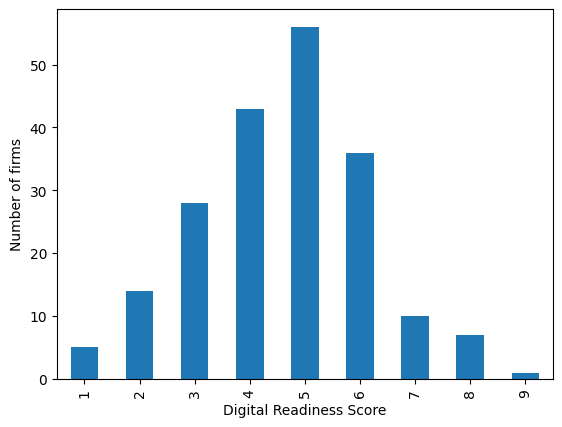

In [20]:
ax = roadmaps_df[drs_col_name].value_counts().sort_index().plot.bar()
ax.set_ylabel('Number of firms')
ax.set_xlabel('Digital Readiness Score')
ax

## Attempting to fit the data to a binomial distrbution

In [21]:
res = scipy.stats.fit(
    scipy.stats.binom,
    roadmaps_df[roadmaps_df[drs_col_name].notna()][drs_col_name],
    bounds={"n": [1,9]}
)
res.params

FitParams(n=np.float64(9.0), p=np.float64(0.511111105455773), loc=np.float64(0.0))

In [22]:
# res.plot()

In [23]:
nllf = res.nllf()
math.exp(-nllf)

1.7051864400238184e-162

## Attempting to fit to a normal distribution

In [24]:
mu, sigma = scipy.stats.norm.fit(roadmaps_df[roadmaps_df[drs_col_name].notna()][drs_col_name])
print(f'mu={mu}, sigma={sigma}')

mu=4.6, sigma=1.5556349186104046


In [25]:
res = scipy.stats.norm.fit(
    roadmaps_df[roadmaps_df[drs_col_name].notna()][drs_col_name]
)
res

(np.float64(4.6), np.float64(1.5556349186104046))

In [26]:
gof = scipy.stats.goodness_of_fit(
    scipy.stats.norm,
    roadmaps_df[roadmaps_df[drs_col_name].notna()][drs_col_name],
)
gof.pvalue

np.float64(0.0001)

In [27]:
scipy.stats.skewtest(roadmaps_df[roadmaps_df[drs_col_name].notna()][drs_col_name])

SkewtestResult(statistic=np.float64(-0.019038788345384333), pvalue=np.float64(0.9848101623856013))

In [28]:
scipy.stats.kurtosistest(roadmaps_df[roadmaps_df[drs_col_name].notna()][drs_col_name])

KurtosistestResult(statistic=np.float64(0.07270946288623555), pvalue=np.float64(0.9420373181890123))

## DRS vs Digital Champion

In [29]:
champion_col = 'Do you have a Digital Champion in place?'
roadmaps_df[champion_col].value_counts(dropna=False)

,count
Do you have a Digital Champion in place?,
True,122
False,77
NaN,21


Text(0.5, 0, 'Expert-assigned DRS')

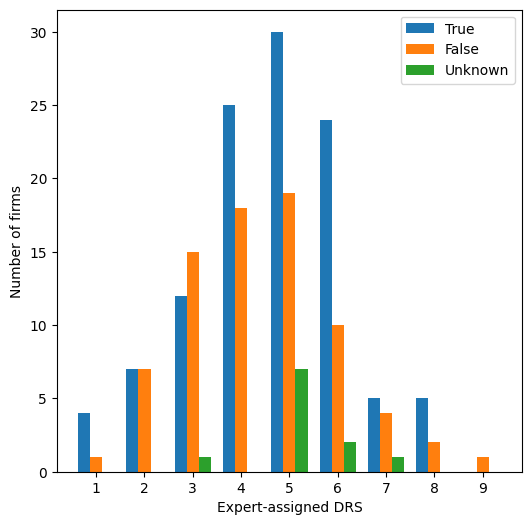

In [30]:
n_categories = len(roadmaps_df[champion_col].unique())
x = numpy.arange(1, len(DRS_LEVELS)+1)
width = 1/(n_categories+1)

fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))

multiplier = -1

for champ in [True, False]:
  offset = width * multiplier
  y = roadmaps_df[roadmaps_df[champion_col] == champ].groupby(drs_col_name).size()
  y = y.reindex(range(1, len(DRS_LEVELS)+1), fill_value=0)
  rects = ax.bar(
      x + offset,
      y,
      width,
      label=champ
  )
  multiplier += 1

offset = width * multiplier
y = roadmaps_df[roadmaps_df[champion_col].isna()].groupby(drs_col_name).size()
y = y.reindex(range(1, len(DRS_LEVELS)+1), fill_value=0)
rects = ax.bar(
    x + offset,
    y,
    width,
    label=champ
)
rects.set_label('Unknown')

ax.set_xticks(x)

ax.legend()

ax.set_ylabel('Number of firms')
ax.set_xlabel('Expert-assigned DRS')

# Feedback

In [31]:
feedback_cols = [
    'How valuable did you find the involvement of your contact within the programme during the course of the support?',
    'How valuable did you find the GROWTHmapper and its report in identifying the key areas of supporting your business?',
    'How valuable did you find the support you received from the Expert Coach during the course of the programme?'
]

for col in feedback_cols:
  feedback_srs = roadmaps_df[col].dropna()
  print(f"{col} Mean {feedback_srs.mean():.2f}; Std {feedback_srs.std():.2f}")

How valuable did you find the involvement of your contact within the programme during the course of the support? Mean 4.87; Std 0.40
How valuable did you find the GROWTHmapper and its report in identifying the key areas of supporting your business? Mean 4.46; Std 0.65
How valuable did you find the support you received from the Expert Coach during the course of the programme? Mean 4.85; Std 0.41


# Text

In [32]:
qual_cols = [
    'Summary review of Edge Digital diagnostic report & current state and key improvement areas',
    'What are the internal barriers to growth? How do you intend to finance future growth? Are there sufficient leadership and management skills in the business to achieve your growth? What opportunities do you have to expand into new markets?',
    'Details of any existing Digital Strategy', # Check: Rob added in on 21st May
    'Level of current Strategic Digital Skills/knowledge in the business',
    'Level of current Technical Digital Skills/knowledge in the business',
    'Whether the business is already investing/adopting/utilising Industry 4.0 Technologies, with examples',
    'Summary of the identified problems, including Gap Analysis'
]

short_labels = [
    "1. Edge Digital",
    "2. Investment barriers",
    "3. Existing strategy",
    "4. Strategic skills",
    "5. Technical skills",
    "6. Already investing?",
    "7. Identified problems"
]

Text(0, 0.5, 'Word count')

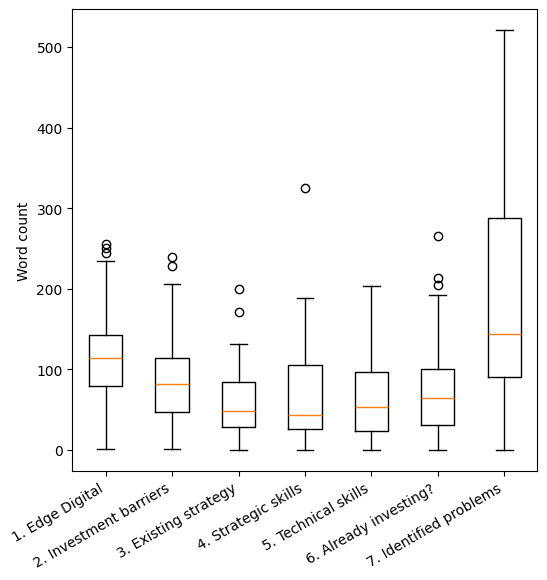

In [33]:
box_data = []
for i, col in enumerate(qual_cols):
  box_data.append(roadmaps_df[col].apply(lambda x: len(str(x).split())).to_numpy())

fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))
ax.boxplot(box_data)
ax.set_xticklabels(short_labels, rotation=30, ha="right")
ax.set_ylabel('Word count')

In [34]:
roadmaps_df['Summary of the identified problems, including Gap Analysis'].apply(lambda x: len(str(x).split())).max()

521

In [35]:
roadmaps_df['Summary of the identified problems, including Gap Analysis'].apply(lambda x: len(str(x).split())>500).value_counts()

,count
"Summary of the identified problems, including Gap Analysis",
False,219
True,1


In [36]:
qual_df = roadmaps_df[['Client ID', 'Current Digital Readiness Score (refer to PAS:1040)'] + qual_cols].copy()
# qual_df = qual_df[roadmaps_df[drs_col_name].notna()]
qual_df['Context'] = roadmaps_df.apply(lambda row: ' '.join(filter(None, [row[c] for c in qual_cols])), axis=1)
qual_df.drop(qual_cols, axis=1, inplace=True)
qual_df["Word Count"] = qual_df["Context"].apply(lambda x: len(str(x).split()))
qual_df

,Client ID,Current Digital Readiness Score (refer to PAS:1040),Context,Word Count
0,e9b5b5a2-1ba0-1d3a-a374-67ed061c1e40,<NA>,Summary review of [REDACTED] diagnostic report...,534
1,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,6,The business scored 6 on their self assessed E...,833
2,65CE53AE-8233-D485-957C-705AF17CCE77,4,Based on the output from the self completed [R...,1069
3,C713DA4C-F07B-F227-351A-5C376EC69358,5,The EDD correctly identifies that [REDACTED]ha...,621
4,5b2c583d-380d-dc1f-6136-670501a9cb82,6,The business has been given access to but as y...,966
...,...,...,...,...
215,97917D20-3915-F182-D8AB-90025E1384E3,4,"Although the report shows a DRL of 4, they are...",94
216,ae14d7b9-0d2e-cbec-c060-6749e01e45f5,4,A PAS score of 4 would appear to be a little h...,762
217,7A707463-E7C6-35F6-C547-659B9F10AE91,3,Company has invested some data and digital tec...,961
218,5FF419AC-6BD3-91D0-6938-FE8C0909F895,6,"[REDACTED]benchmarks well against its peers, e...",489


/tmp/ipykernel_15124/1277527442.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bins, rotation=30)


[Text(0, 0, '0-127'),
 Text(1, 0, '128-255'),
 Text(2, 0, '256-383'),
 Text(3, 0, '384-511'),
 Text(4, 0, '512-639'),
 Text(5, 0, '640-767'),
 Text(6, 0, '768-895'),
 Text(7, 0, '896-1023')]

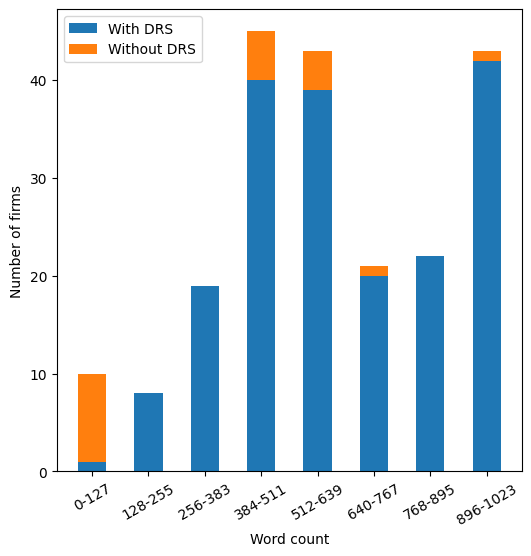

In [37]:
step = 128
n_bins = 8
bins = []
weight_counts = {
    "With DRS": numpy.zeros(n_bins),
    "Without DRS": numpy.zeros(n_bins)
}

for i in range(0, n_bins*step, step):
  bins.append(f"{i}-{i+step-1}")
  weight_counts["With DRS"][int(i/step)] = qual_df[
      qual_df[drs_col_name].notna() &
      (qual_df['Word Count'] >= i) &
      (qual_df['Word Count'] < i+step)
    ]['Word Count'].count()
  weight_counts["Without DRS"][int(i/step)] = qual_df[
      qual_df[drs_col_name].isna() &
      (qual_df['Word Count'] >= i) &
      (qual_df['Word Count'] < i+step)
    ]['Word Count'].count()

bottom = numpy.zeros(len(bins))
width = 0.5
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))

for drs_label, weight_count in weight_counts.items():
    p = ax.bar(bins, weight_count, width, label=drs_label, bottom=bottom)
    bottom += weight_count

ax.set_ylabel('Number of firms')
ax.set_xlabel('Word count')
ax.legend()
ax.set_xticklabels(bins, rotation=30)


Chunk the text that is longer than 510 words sentencewise, and see if this can split the longest text blocks into just two.

In [38]:
has_text_mask = is_non_empty(qual_df['Context'])
qual_df['Chunked Text'] = qual_df['Context'].apply(lambda x: [] if x == '' else chunk_text_sentencewise(x, 510))
qual_df['N chunks'] = qual_df['Chunked Text'].apply(len)
qual_df['N chunks'].value_counts().sort_index()

,count
N chunks,
1,79
2,125
3,16


<Axes: xlabel='Current Digital Readiness Score (refer to PAS:1040)', ylabel='Word Count'>

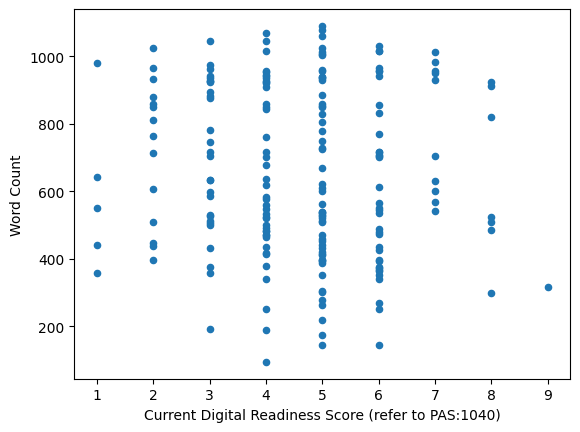

In [39]:
qual_df.plot.scatter(drs_col_name, 'Word Count')

# All Variables

## Key variables with labels

In [80]:
key_vars = [
    # DV
    ('Total firm contribution', 'Technology Adoption Efforts'),

    # Explanatory
    ## Readiness
    ('Current Digital Readiness Score (refer to PAS:1040)', 'DRS'),
    ('Do you have a Digital Champion in place?', 'Digital Champion?'),
    ## Perceptions
    ('How valuable did you find the involvement of your contact within the programme during the course of the support?', 'Engagement'),
    ('How valuable did you find the GROWTHmapper and its report in identifying the key areas of supporting your business?', 'Roadmap'),
    ('How valuable did you find the support you received from the Expert Coach during the course of the programme?', 'Expert Advice'),
    ## WCC
    ('Willingness', 'Willingness'),
    ('Capability', 'Capability'),
    ('Capacity', 'Capacity'),

    # Control
    ('Number of GAFs', 'Number of Applications'),
    ('Is Micro?', 'Is Micro?'),
    ('Is Medium?', 'Is Medium?'),
]

## Pairwise correlations

In [86]:
corr_df = roadmaps_df[[tpl[0] for tpl in key_vars]]
corr_df = corr_df.dropna()
corr_df.rename(columns={tpl[0]: tpl[1] for tpl in key_vars}, inplace=True)
# corr_df

In [60]:
pval = corr_df.corr(method=lambda x, y: scipy.stats.pearsonr(x, y)[1]) - numpy.eye(N=len(key_vars))
# pval

In [61]:
def significance_map(pval):
  if pval < 0.01:
    return '**'
  elif pval < 0.05:
    return '*'
  elif pval < 0.1:
    return '+'
  else:
    return ''

p = pval.map(lambda x: significance_map(x))
# p

In [62]:
corr_df.corr().round(2).astype(str) + p

,Technology Adoption Efforts,DRS,Digital Champion?,Engagement,Roadmap,Expert Advice,Willingness,Capability,Capacity,Number of Applications,Is Micro?,Is Medium?
Technology Adoption Efforts,1.0**,0.06,-0.11,0.02,-0.03,0.12,0.17*,0.09,0.15+,0.36**,-0.08,0.19*
DRS,0.06,1.0**,0.09,0.04,-0.11,0.01,0.1,0.18*,0.09,-0.03,-0.05,0.06
Digital Champion?,-0.11,0.09,1.0**,0.11,-0.04,0.06,-0.16+,-0.1,-0.13,0.13,-0.07,0.06
Engagement,0.02,0.04,0.11,1.0**,0.44**,0.73**,0.08,0.15+,0.07,0.02,-0.05,-0.0
Roadmap,-0.03,-0.11,-0.04,0.44**,1.0**,0.53**,0.22**,0.19*,0.19*,-0.09,0.02,-0.11
Expert Advice,0.12,0.01,0.06,0.73**,0.53**,1.0**,0.08,0.13,0.05,0.06,-0.02,-0.06
Willingness,0.17*,0.1,-0.16+,0.08,0.22**,0.08,1.0**,0.73**,0.89**,-0.07,0.1,0.01
Capability,0.09,0.18*,-0.1,0.15+,0.19*,0.13,0.73**,1.0**,0.78**,0.05,0.02,0.06
Capacity,0.15+,0.09,-0.13,0.07,0.19*,0.05,0.89**,0.78**,1.0**,-0.08,0.11,0.08
Number of Applications,0.36**,-0.03,0.13,0.02,-0.09,0.06,-0.07,0.05,-0.08,1.0**,-0.13,0.04


## OLS model

In [87]:
X = corr_df.drop(columns=['Technology Adoption Efforts'])
y = corr_df['Technology Adoption Efforts']
X2 = statsmodels.api.add_constant(X)
est = statsmodels.api.OLS(y, X2.astype(float))
est2 = est.fit()
print(est2.summary())

                                 OLS Regression Results                                
Dep. Variable:     Technology Adoption Efforts   R-squared:                       0.263
Model:                                     OLS   Adj. R-squared:                  0.201
Method:                          Least Squares   F-statistic:                     4.245
Date:                         Wed, 17 Jun 2026   Prob (F-statistic):           2.17e-05
Time:                                 11:08:04   Log-Likelihood:                -1294.4
No. Observations:                          143   AIC:                             2613.
Df Residuals:                              131   BIC:                             2648.
Df Model:                                   11                                         
Covariance Type:                     nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

In [66]:
X.shape

(143, 11)